<a href="https://colab.research.google.com/github/Aaditya-git/Aaditya-git/blob/main/HW_3_task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-surprise


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2555148 sha256=81ad3a78aa0e95b40ec7b7f1c55539f5ec94900aca8e149fe8e800ebf977cc58
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [2]:
!pip uninstall -y numpy

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [3]:
!pip install --no-cache-dir "numpy==1.26.4" "scipy==1.11.4"
!pip install --no-cache-dir "cython<3.0" "pybind11<2.12"
!pip install --no-cache-dir "scikit-surprise==1.1.4" pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 257.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 143.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; pyth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.3/229.3 kB 306.9 MB/s eta 0:00:00
  Attempting uninstall: cython
    Found existing installation: Cython 3.0.12
    Uninstalling Cython-3.0.12:
      Successfully uninstalled Cython-3.0.12


In [15]:
import numpy, surprise
print("NumPy:", numpy.__version__)
print("surprise:", surprise.__version__)

NumPy: 1.26.4
surprise: 1.1.4


In [8]:

CSV_PATH = "/content/ratings_small.csv"   # if you want to run thsi , add your file under sample data and run it. :)
RATING_SCALE = (0.5, 5.0)
SEED = 123
FOLDS = 5

# === IMPORTS ===
import os, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import KFold, cross_validate

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"File not found at {CSV_PATH}. Upload it to Colab and update CSV_PATH.")
raw = pd.read_csv(CSV_PATH)

need = {"userId","movieId","rating"}
if not need.issubset(raw.columns):
    raise ValueError(f"CSV must contain columns {need}, found {set(raw.columns)}")

reader = Reader(rating_scale=RATING_SCALE)
data = Dataset.load_from_df(raw[["userId","movieId","rating"]], reader)

kf = KFold(n_splits=FOLDS, random_state=SEED, shuffle=True)
print(f"Loaded {len(raw):,} rows; using {FOLDS}-fold CV with seed {SEED}.")


Loaded 100,004 rows; using 5-fold CV with seed 123.


In [10]:
def mean_and_sem(values):
    arr = np.asarray(values, dtype=float)
    mean = float(arr.mean())
    sem = float(arr.std(ddof=1) / math.sqrt(len(arr))) if len(arr) > 1 else 0.0
    return mean, sem

def cv_scores_for(algo, kf):
    cv = cross_validate(algo, data, measures=["MAE","RMSE"], cv=kf, verbose=False)
    return {"mae": list(cv["test_mae"]), "rmse": list(cv["test_rmse"])}

def summarize_block(title, rows, save_csv_path):
    df = pd.DataFrame(rows)
    display(df.sort_values("RMSE"))
    if save_csv_path:
        df.to_csv(save_csv_path, index=False)
        print(f"Saved: {save_csv_path}")
    if title:
        print(f"— {title} complete —")
    return df.sort_values("RMSE")


In [20]:
# ===== (c) & (d) PMF (biased=False) vs CF on SAME CV splits =====
from surprise import SVD, KNNBasic, accuracy
from surprise.model_selection import KFold
import numpy as np
import pandas as pd

def make_splits(surp_dataset, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, random_state=seed, shuffle=True)
    return list(kf.split(surp_dataset))

def evaluate_on_splits(surp_dataset, algo, splits):
    maes, rmses = [], []
    for trainset, testset in splits:
        algo.fit(trainset)
        preds = algo.test(testset)
        maes.append(accuracy.mae(preds, verbose=False))
        rmses.append(accuracy.rmse(preds, verbose=False))
    return float(np.mean(maes)), float(np.mean(rmses))

splits = make_splits(data, n_splits=5, seed=42)


pmf_candidates = [
    {"n_factors": 50,  "n_epochs": 25, "lr_all": 0.005, "reg_all": 0.05},
    {"n_factors": 80,  "n_epochs": 30, "lr_all": 0.005, "reg_all": 0.07},
    {"n_factors": 100, "n_epochs": 35, "lr_all": 0.004, "reg_all": 0.08},
    {"n_factors": 120, "n_epochs": 40, "lr_all": 0.004, "reg_all": 0.10},
]

best_pmf = None
for p in pmf_candidates:
    algo = SVD(biased=False, random_state=42, **p)
    mae, rmse = evaluate_on_splits(data, algo, splits)
    if (best_pmf is None) or (rmse < best_pmf["RMSE"]):
        best_pmf = {"params": p, "MAE": mae, "RMSE": rmse}

print("Best pure-PMF params (by RMSE):", best_pmf["params"])
print(f"  -> MAE={best_pmf['MAE']:.4f}, RMSE={best_pmf['RMSE']:.4f}")

def run_cf(user_based=True, sim_name="cosine", k=40):
    sim_options = {"name": sim_name, "user_based": user_based}
    return KNNBasic(k=k, sim_options=sim_options)

results = []

# PMF (pure, tuned)
pmf_algo = SVD(biased=False, random_state=42, **best_pmf["params"])
mae, rmse = evaluate_on_splits(data, pmf_algo, splits)
results.append(dict(model="PMF (biased=False, tuned)", sim="-", k="-", MAE=mae, RMSE=rmse))


for ub in [True, False]:
    model = "UserCF" if ub else "ItemCF"
    cf_algo = run_cf(user_based=ub, sim_name="cosine", k=40)
    mae, rmse = evaluate_on_splits(data, cf_algo, splits)
    results.append(dict(model=model, sim="cosine", k=40, MAE=mae, RMSE=rmse))

cv_summary = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(cv_summary)

cv_summary.to_csv("/content/cv_summary.csv", index=False)
print("Saved: /content/cv_summary.csv")

best_row = cv_summary.iloc[0]
print(f"(d) Best by RMSE: {best_row['model']} (sim={best_row['sim']}, k={best_row['k']}) with RMSE={best_row['RMSE']:.5f}")


Best pure-PMF params (by RMSE): {'n_factors': 80, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.07}
  -> MAE=0.7452, RMSE=0.9661
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.


,model,sim,k,MAE,RMSE
0,"PMF (biased=False, tuned)",-,-,0.745241,0.966082
1,UserCF,cosine,40,0.767113,0.993150
2,ItemCF,cosine,40,0.774792,0.995100


Saved: /content/cv_summary.csv
(d) Best by RMSE: PMF (biased=False, tuned) (sim=-, k=-) with RMSE=0.96608


Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd sim

,type,sim,k,RMSE,MAE
0,ItemCF,cosine,50,0.991215,0.770780
1,ItemCF,msd,50,0.933314,0.719691
2,ItemCF,pearson,50,0.985597,0.764146
3,UserCF,cosine,50,0.994127,0.768561
4,UserCF,msd,50,0.970972,0.747073
5,UserCF,pearson,50,0.999534,0.773141


Saved: /content/similarity_summary.csv


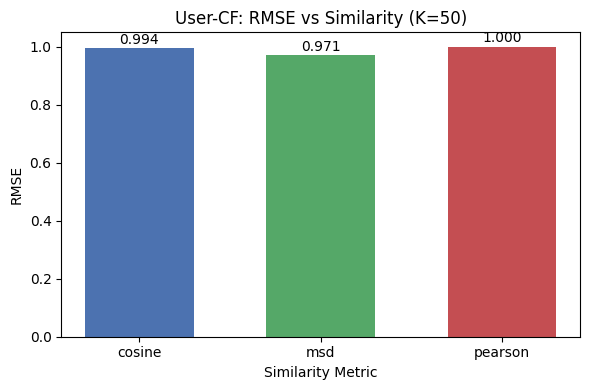

Saved: /content/usercf_rmse_vs_similarity.png


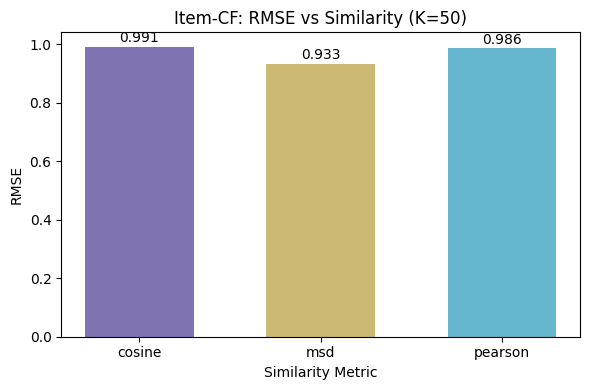

Saved: /content/itemcf_rmse_vs_similarity.png


In [18]:
similarities = ["cosine", "msd", "pearson"]
k_fixed = 50

rows = []
for sim in similarities:
    algo_u = KNNBasic(k=k_fixed, sim_options={"name": sim, "user_based": True})
    sc_u = cv_scores_for(algo_u, kf)
    rows.append({
        "type": "UserCF", "sim": sim, "k": k_fixed,
        "RMSE": float(np.mean(sc_u["rmse"])),
        "MAE":  float(np.mean(sc_u["mae"]))
    })

    algo_i = KNNBasic(k=k_fixed, sim_options={"name": sim, "user_based": False})
    sc_i = cv_scores_for(algo_i, kf)
    rows.append({
        "type": "ItemCF", "sim": sim, "k": k_fixed,
        "RMSE": float(np.mean(sc_i["rmse"])),
        "MAE":  float(np.mean(sc_i["mae"]))
    })

sim_df = pd.DataFrame(rows).sort_values(["type", "sim"]).reset_index(drop=True)
display(sim_df)
sim_df.to_csv("/content/similarity_summary.csv", index=False)
print("Saved: /content/similarity_summary.csv")


user_rmse = [sim_df[(sim_df.type=="UserCF") & (sim_df.sim==s)]["RMSE"].values[0] for s in similarities]
colors = ["#4C72B0", "#55A868", "#C44E52"]  # adding colors for fun :)

plt.figure(figsize=(6,4))
bars = plt.bar(similarities, user_rmse, color=colors, width=0.6)
plt.title("User-CF: RMSE vs Similarity (K=50)")
plt.ylabel("RMSE")
plt.xlabel("Similarity Metric")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.3f}",
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
plt.savefig("/content/usercf_rmse_vs_similarity.png", dpi=150)
plt.close()
print("Saved: /content/usercf_rmse_vs_similarity.png")

item_rmse = [sim_df[(sim_df.type=="ItemCF") & (sim_df.sim==s)]["RMSE"].values[0] for s in similarities]
colors = ["#8172B2", "#CCB974", "#64B5CD"]

plt.figure(figsize=(6,4))
bars = plt.bar(similarities, item_rmse, color=colors, width=0.6)
plt.title("Item-CF: RMSE vs Similarity (K=50)")
plt.ylabel("RMSE")
plt.xlabel("Similarity Metric")


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.3f}",
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
plt.savefig("/content/itemcf_rmse_vs_similarity.png", dpi=150)
plt.close()
print("Saved: /content/itemcf_rmse_vs_similarity.png")


Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing th

,K,RMSE,MAE
0,5,1.041618,0.803765
1,10,1.010260,0.778610
2,20,0.997632,0.769294
3,30,0.994680,0.767734
4,40,0.994023,0.768040
5,50,0.994127,0.768561
6,60,0.994469,0.769378
7,80,0.995010,0.770484
8,100,0.995683,0.771539


,K,RMSE,MAE
0,5,1.106408,0.863868
1,10,1.054920,0.823595
2,20,1.020426,0.795535
3,30,1.005947,0.783137
4,40,0.997058,0.775577
5,50,0.991215,0.770780
6,60,0.986964,0.767109
7,80,0.981823,0.762516
8,100,0.978668,0.759939


Saved: /content/usercf_k_sweep_cosine.csv
Saved: /content/itemcf_k_sweep_cosine.csv


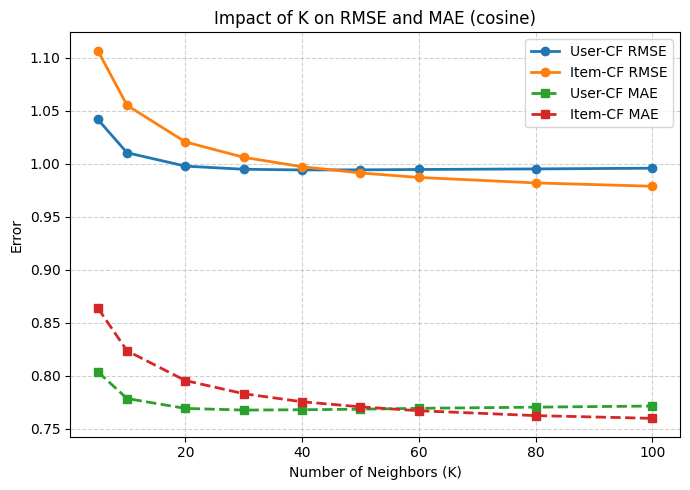

Saved: /content/error_vs_k.png
(g) Best K — User-CF: 40, Item-CF: 100


In [21]:


k_grid = [5, 10, 20, 30, 40, 50,60,80,100] # we can tweak these values :)
sim_for_sweep = "cosine"

def sweep_rmse_mae_k(user_based: bool):
    """Run 5-fold CV for each K and return mean RMSE/MAE."""
    vals = []
    for k in k_grid:
        algo = KNNBasic(k=k, sim_options={"name": sim_for_sweep, "user_based": user_based})
        sc = cv_scores_for(algo, kf)
        vals.append({
            "K": k,
            "RMSE": float(np.mean(sc["rmse"])),
            "MAE": float(np.mean(sc["mae"]))
        })
    return pd.DataFrame(vals)


user_k = sweep_rmse_mae_k(user_based=True)
item_k = sweep_rmse_mae_k(user_based=False)


display(user_k)
display(item_k)
user_k.to_csv("/content/usercf_k_sweep_cosine.csv", index=False)
item_k.to_csv("/content/itemcf_k_sweep_cosine.csv", index=False)
print("Saved: /content/usercf_k_sweep_cosine.csv")
print("Saved: /content/itemcf_k_sweep_cosine.csv")


plt.figure(figsize=(7,5))
plt.plot(user_k["K"], user_k["RMSE"], marker="o", linewidth=2, label="User-CF RMSE")
plt.plot(item_k["K"], item_k["RMSE"], marker="o", linewidth=2, label="Item-CF RMSE")
plt.plot(user_k["K"], user_k["MAE"],  marker="s", linestyle="--", linewidth=2, label="User-CF MAE")
plt.plot(item_k["K"], item_k["MAE"],  marker="s", linestyle="--", linewidth=2, label="Item-CF MAE")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error")
plt.title("Impact of K on RMSE and MAE (cosine)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
plt.savefig("/content/error_vs_k.png", dpi=150)
plt.close()
print("Saved: /content/error_vs_k.png")


best_k_user = int(user_k.loc[user_k["RMSE"].idxmin(), "K"])
best_k_item = int(item_k.loc[item_k["RMSE"].idxmin(), "K"])
print(f"(g) Best K — User-CF: {best_k_user}, Item-CF: {best_k_item}")


In [22]:

for p in [
    "/content/metrics_overview.csv",
    "/content/similarity_summary.csv",
    "/content/similarity_impact.png",
    "/content/usercf_rmse_vs_k.csv",
    "/content/itemcf_rmse_vs_k.csv",
    "/content/neighbors_impact_user.png",
    "/content/neighbors_impact_item.png",
]:
    print(" -", p)


 - /content/metrics_overview.csv
 - /content/similarity_summary.csv
 - /content/similarity_impact.png
 - /content/usercf_rmse_vs_k.csv
 - /content/itemcf_rmse_vs_k.csv
 - /content/neighbors_impact_user.png
 - /content/neighbors_impact_item.png
